# Fit-fraction averages across bins and samples

This notebook loads every configured dataset × bin × emission-line × fit-limit result, applies a group-specific fit-limit selection, converts s0 from pc to arcsec, and makes the two requested comparisons. Multiple limits are averaged; one limit is used directly without averaging.

1. emission lines compared across binning levels;
2. MUSE, MUSE trim, and KPNO compared with emission lines on the x-axis.

All reusable logic is in fit_fraction_analysis.py. Normally you only need to edit the configuration cells below.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR
import results_comp
import fit_fraction_group_limits as ffa
import importlib
ffa = importlib.reload(ffa)

sns.set_context("talk")


## 1. Configure all input result grids

The filename templates reproduce the supplied notebooks. MUSE sulfur is given the plotting key S2 because it is [S III], while KPNO S is [S II].


In [15]:
FIT_LIMITS = (0.3, 0.4, 0.5, 0.6, 0.7, 0.8)
FIT_LIMITS_BY_GROUP = {
    # Two or more limits -> mean plus full uncertainty envelope.
    # One limit -> use that fit directly, without averaging.
    "MUSE": (0.4, 0.5, 0.6),
    "MUSE trim": (0.5, 0.6, 0.7),
    "KPNO": (0.4, 0.5, 0.6),
}

DATASET_CONFIGS = [
    {
        "group": "MUSE",
        "dataset_prefix": "MUSE-M42",
        "bin_levels": (0, 1, 2, 3, 4),
        "line_order": ("N", "S2", "Ar", "H", "O"),
        "file_line_ids": {"S2": "S"},
        "filename_template": "{dataset_prefix}-{file_line}-bin{bin}_{fit_tag}",
    },
    {
        "group": "MUSE trim",
        "dataset_prefix": "MUSE-M42",
        "bin_levels": (2,),
        "line_order": ("N", "H", "O"),
        "filename_template": "{dataset_prefix}-{file_line}-bin{bin}_trim_{fit_tag}",
    },
    {
        "group": "KPNO",
        "dataset_prefix": "KPNO-M42",
        "bin_levels": (0,),
        "line_order": ("N", "S", "H", "O"),
        "filename_template": "{dataset_prefix}-{file_line}-bin{bin}_{fit_tag}",
    },
]

LINE_LABELS = {
    "H": r"H$\alpha$",
    "N": r"[N II]",
    "O": r"[O III]",
    "S": r"[S II]",
    "S2": r"[S III]",
    "Ar": r"[Ar III]",
}

line_legend_labels = {
    "H": r"H$\alpha$ $\lambda$6563",
    "N": r"[N II] $\lambda$6583",
    "O": r"[O III] $\lambda$5007",
    "S2": r"[S III] $\lambda$9069",
    "Ar": r"[Ar III] $\lambda$7136",
}

PARAM_LABELS_ARCSEC = {
    "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
    "r0": r"$r_0$ [pc]",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
    "s0": r"$s_0$ [arcsec]",
}

PARAM_YLIMS_ARCSEC = {
    "sig2": (0, 20),
    "r0": (0, 0.12),
    "m": (0.5, 1.5),
    "noise": (-1, 10),
    "s0": (0, 3),
}

SAVE_FIGURES = False


## 2. Preview and load every fraction result

Use on_error="raise" when the grid must be complete. The current "warn" setting skips unavailable combinations and records them in failures.


In [16]:
samples = ffa.build_fraction_sample_grid(DATASET_CONFIGS, FIT_LIMITS)
sample_table = pd.DataFrame(samples)[
    ["group", "bin", "line", "fit_limit", "file_name"]
]
print(f"Configured {len(sample_table)} result files")
display(sample_table.head(12))


Configured 192 result files


,group,bin,line,fit_limit,file_name
0,MUSE,0,N,0.3,MUSE-M42-N-bin0_03
1,MUSE,0,N,0.4,MUSE-M42-N-bin0_04
2,MUSE,0,N,0.5,MUSE-M42-N-bin0_05
3,MUSE,0,N,0.6,MUSE-M42-N-bin0_06
4,MUSE,0,N,0.7,MUSE-M42-N-bin0_07
5,MUSE,0,N,0.8,MUSE-M42-N-bin0_08
6,MUSE,0,S2,0.3,MUSE-M42-S-bin0_03
7,MUSE,0,S2,0.4,MUSE-M42-S-bin0_04
8,MUSE,0,S2,0.5,MUSE-M42-S-bin0_05
9,MUSE,0,S2,0.6,MUSE-M42-S-bin0_06


In [17]:
all_fraction_results, failures = ffa.load_multi_line_bin_fraction_results(
    results_comp,
    MAPS_DIR,
    dataset_configs=DATASET_CONFIGS,
    fit_limits=FIT_LIMITS,
    read_header=True,
    on_error="warn",
    return_failures=True,
)

print(f"Loaded: {len(all_fraction_results)}")
print(f"Unavailable: {len(failures)}")

if failures:
    display(pd.DataFrame(failures)[["file_name", "error"]])


Loaded: 192
Unavailable: 0


## 3. Optional: inspect fraction dependence before averaging

This example compares all fractions for MUSE bin 2. Change RAW_GROUP and RAW_BIN to inspect another sample/bin.


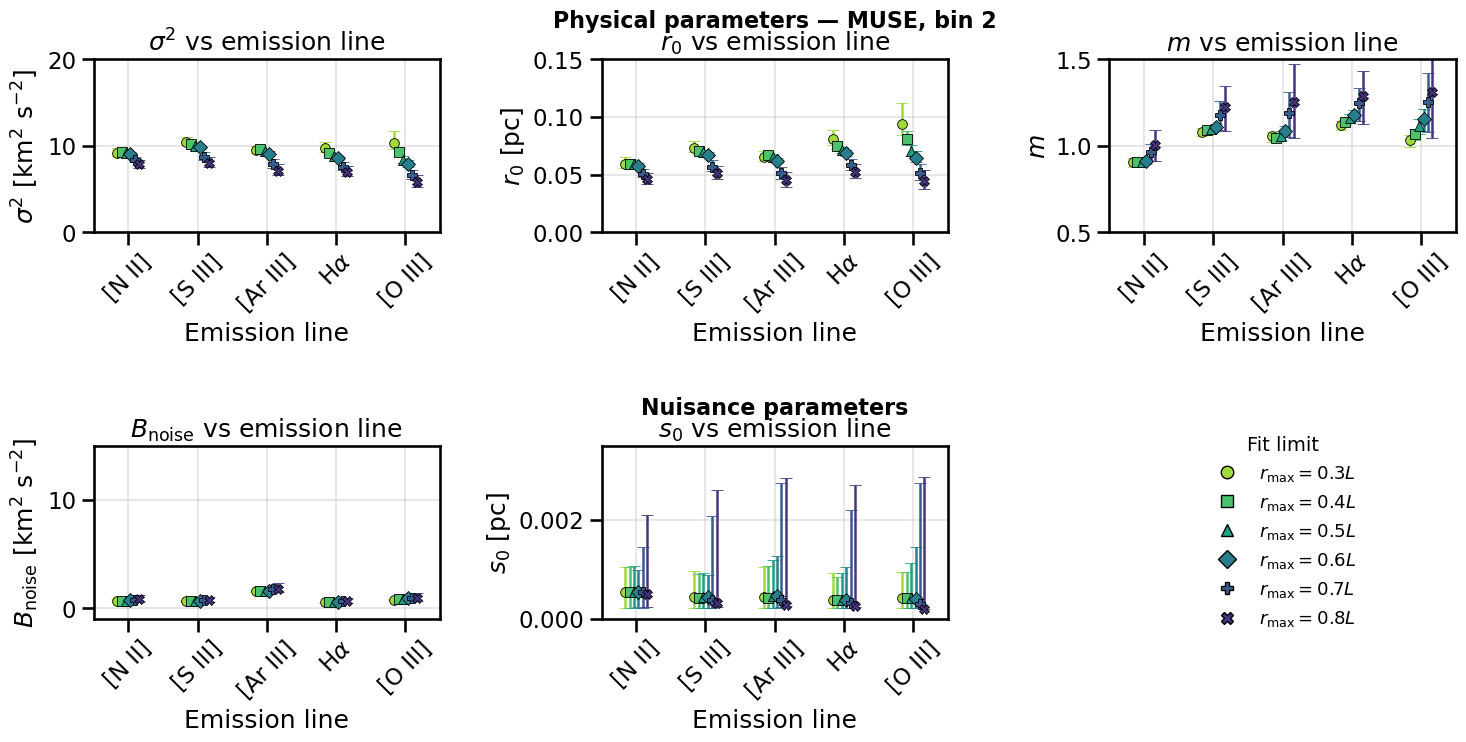

In [18]:
RAW_GROUP = "MUSE"
RAW_BIN = 2

raw_example = ffa.select_results(
    all_fraction_results,
    group=RAW_GROUP,
    bin=RAW_BIN,
)
fraction_labels = tuple(
    rf"$r_\mathrm{{max}} = {value:.1f}L$"
    for value in FIT_LIMITS
)

if raw_example:
    fig_raw, axes_raw = ffa.plot_param_grid_lines_as_x(
        raw_example,
        line_order=("N", "S2", "Ar", "H", "O"),
        group_order=fraction_labels,
        group_key="fit_limit_label",
        line_labels=LINE_LABELS,
        param_ylims={
            "sig2": (0, 20),
            "r0": (0, 0.15),
            "m": (0.5, 1.5),
            "noise": (-1, 15),
            "s0": (0, 0.0035),
        },
        row_titles=(f"Physical parameters — {RAW_GROUP}, bin {RAW_BIN}",
                    "Nuisance parameters"),
        color_palette="viridis",
        jitter=0.16,
        legend_title="Fit limit",
        save=SAVE_FIGURES,
        savepath=FIGS_DIR / f"fit_limits_{RAW_GROUP}_bin{RAW_BIN}.pdf",
    )
    plt.show()
else:
    print("No results are available for the requested raw comparison.")


## 4. Select or average group-specific fit limits

Each group uses its own selection from FIT_LIMITS_BY_GROUP. Two or more limits produce the mean with the full asymmetric envelope. A single limit is passed through unchanged and is not averaged.


In [19]:
selected_results_pc = ffa.select_or_average_fit_results(
    all_fraction_results,
    fit_limits_by_group=FIT_LIMITS_BY_GROUP,
    group_keys=("group", "bin", "line"),
)

selected_table_pc = ffa.results_to_dataframe(selected_results_pc)
print(f"Created {len(selected_results_pc)} selected/averaged line results")
display(selected_table_pc.head(15))


Created 32 selected/averaged line results


,group,bin,line,fit_limit,fit_limits_used,selection_mode,parameter,value,err_lower,err_upper,lower_limit,upper_limit,n_samples
0,MUSE,0,N,None,"(0.4, 0.5, 0.6)",average,sig2,9.220458,3.758161e-01,0.656550,8.844642,9.877007,3
1,MUSE,0,N,None,"(0.4, 0.5, 0.6)",average,r0,0.061635,4.237293e-03,0.008224,0.057398,0.069859,3
2,MUSE,0,N,None,"(0.4, 0.5, 0.6)",average,m,0.883323,3.861927e-02,0.035952,0.844704,0.919276,3
3,MUSE,0,N,None,"(0.4, 0.5, 0.6)",average,noise,3.948431,6.939841e-02,0.124862,3.879032,4.073293,3
4,MUSE,0,N,None,"(0.4, 0.5, 0.6)",average,s0,0.000199,7.342868e-15,0.000236,0.000199,0.000435,3
5,MUSE,0,S2,None,"(0.4, 0.5, 0.6)",average,sig2,9.716018,4.014683e-01,0.611027,9.314550,10.327046,3
6,MUSE,0,S2,None,"(0.4, 0.5, 0.6)",average,r0,0.070703,4.496575e-03,0.006830,0.066206,0.077533,3
7,MUSE,0,S2,None,"(0.4, 0.5, 0.6)",average,m,1.103817,4.231765e-02,0.043812,1.061500,1.147629,3
8,MUSE,0,S2,None,"(0.4, 0.5, 0.6)",average,noise,3.195799,4.557372e-02,0.088333,3.150225,3.284132,3
9,MUSE,0,S2,None,"(0.4, 0.5, 0.6)",average,s0,0.000199,5.680591e-13,0.000403,0.000199,0.000602,3


## 5. Convert selected results' s0 from pc to arcsec

This preserves the central value and both asymmetric uncertainties. The conversion is s0_arcsec = s0_pc × 2.35 / PC, using each result's metadata.


In [20]:
selected_results = ffa.convert_s0_pc_to_arcsec(
    selected_results_pc,
    arcsec_per_pixel=2.35,
    copy=True,
)

selected_table = ffa.results_to_dataframe(selected_results)
display(selected_table.head(15))


,group,bin,line,fit_limit,fit_limits_used,selection_mode,parameter,value,err_lower,err_upper,lower_limit,upper_limit,n_samples
0,MUSE,0,N,None,"(0.4, 0.5, 0.6)",average,sig2,9.220458,3.758161e-01,0.656550,8.844642,9.877007,3
1,MUSE,0,N,None,"(0.4, 0.5, 0.6)",average,r0,0.061635,4.237293e-03,0.008224,0.057398,0.069859,3
2,MUSE,0,N,None,"(0.4, 0.5, 0.6)",average,m,0.883323,3.861927e-02,0.035952,0.844704,0.919276,3
3,MUSE,0,N,None,"(0.4, 0.5, 0.6)",average,noise,3.948431,6.939841e-02,0.124862,3.879032,4.073293,3
4,MUSE,0,N,None,"(0.4, 0.5, 0.6)",average,s0,0.235000,8.681102e-12,0.279198,0.235000,0.514198,3
5,MUSE,0,S2,None,"(0.4, 0.5, 0.6)",average,sig2,9.716018,4.014683e-01,0.611027,9.314550,10.327046,3
6,MUSE,0,S2,None,"(0.4, 0.5, 0.6)",average,r0,0.070703,4.496575e-03,0.006830,0.066206,0.077533,3
7,MUSE,0,S2,None,"(0.4, 0.5, 0.6)",average,m,1.103817,4.231765e-02,0.043812,1.061500,1.147629,3
8,MUSE,0,S2,None,"(0.4, 0.5, 0.6)",average,noise,3.195799,4.557372e-02,0.088333,3.150225,3.284132,3
9,MUSE,0,S2,None,"(0.4, 0.5, 0.6)",average,s0,0.235000,6.715876e-10,0.476233,0.235000,0.711233,3


## 6. Compare the selected MUSE results across binning levels


In [21]:
muse_selected = ffa.select_results(selected_results, group="MUSE")
available_muse_bins = tuple(sorted({entry["bin"] for entry in muse_selected}))
bin_tick_labels = {
    value: "$" + r"{} \times {}$".format(2**value, 2**value)
    for value in available_muse_bins
}

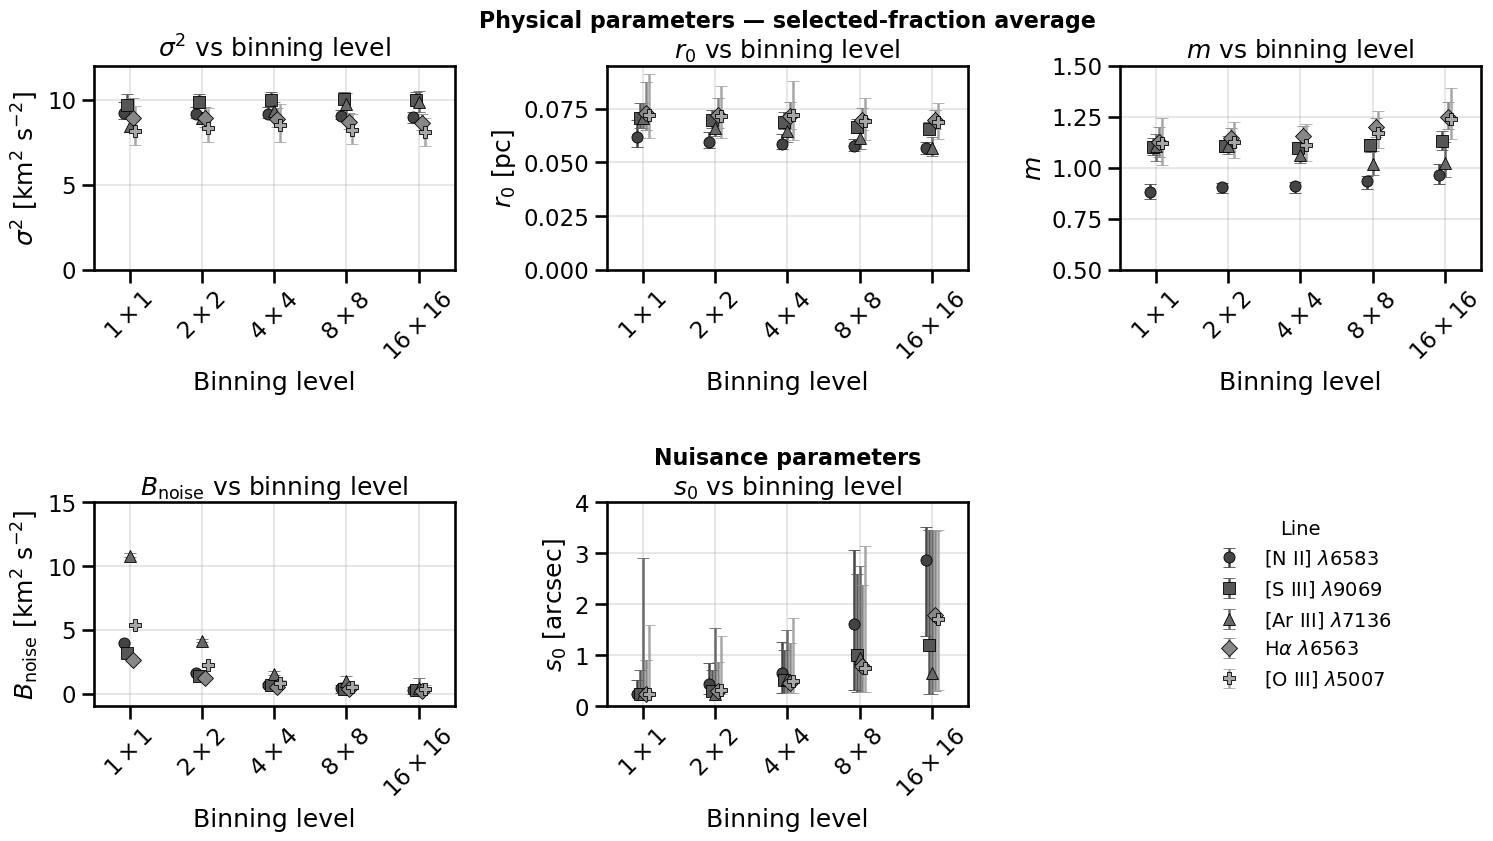

In [25]:
fig_bins, axes_bins = ffa.plot_param_grid_lines_bins(
    muse_selected,
    group="MUSE",
    line_order=("N", "S2", "Ar", "H", "O"),
    bin_levels=available_muse_bins,
    xtick_labels=bin_tick_labels,
    line_legend_labels=line_legend_labels,
    param_labels=PARAM_LABELS_ARCSEC,
    param_ylims={
    "sig2": (0, 12),
    "r0": (0, 0.095),
    "m": (0.5, 1.5),
    "noise": (-1, 15),
    "s0": (0, 4),
    },
    row_titles=(
        "Physical parameters — selected-fraction average",
        "Nuisance parameters",
    ),
    figsize=(15, 9),
    markersize=8,
    legend_fontsize=14,
    jitter=0.08,
    save=SAVE_FIGURES,
    savepath=FIGS_DIR / "fit_fraction_average_by_bin.pdf",
)

for ax in axes_bins[:5]:
    ax.set_box_aspect(None)
    ax.set_aspect("auto")

fig_bins.subplots_adjust(
    left=0.065,
    right=0.99,
    wspace=0.42,
)

plt.show()

## 7. Compare MUSE, MUSE trim, and KPNO by emission line

The selected comparison follows the supplied notebooks: MUSE bin 2, MUSE trim bin 2, and KPNO bin 0. Edit SAMPLE_BIN if you want a different representative bin.


In [26]:
SAMPLE_BIN = {
    "MUSE": 2,
    "MUSE trim": 2,
    "KPNO": 0,
}

sample_selected = [
    entry
    for entry in selected_results
    if entry.get("bin") == SAMPLE_BIN.get(entry.get("group"))
]


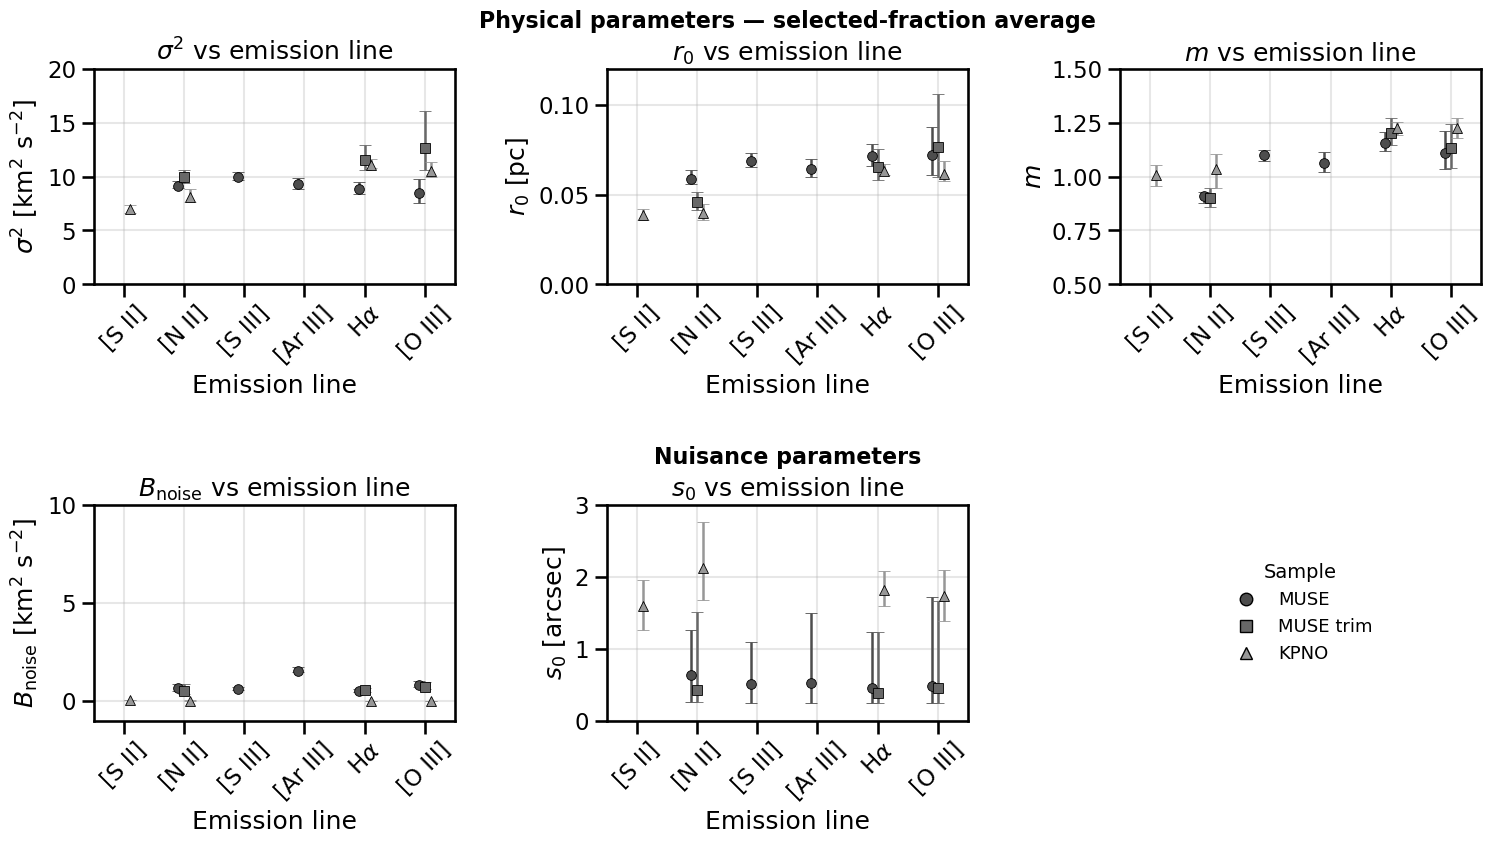

In [27]:
fig_samples, axes_samples = ffa.plot_param_grid_lines_as_x(
    sample_selected,
    line_order=("S", "N", "S2", "Ar", "H", "O"),
    group_order=("MUSE", "MUSE trim", "KPNO"),
    group_key="group",
    line_labels=LINE_LABELS,
    param_labels=PARAM_LABELS_ARCSEC,
    param_ylims=PARAM_YLIMS_ARCSEC,
    row_titles=(
        "Physical parameters — selected-fraction average",
        "Nuisance parameters",
    ),
    row_title_fontsize=16,
    figsize=(15, 9),
    jitter=0.10,
    save=SAVE_FIGURES,
    savepath=FIGS_DIR / "fit_fraction_average_by_sample.pdf",
)

for ax in axes_samples[:5]:
    ax.set_box_aspect(None)
    ax.set_aspect("auto")

fig_samples.subplots_adjust(
    left=0.065,
    right=0.99,
    wspace=0.42,
)

plt.show()

## 8. Optional export of the selected/averaged values


In [33]:
OUTPUT_TABLE = ROOT / "fit_fraction_selected_results.csv"
selected_table.to_csv(OUTPUT_TABLE, index=False)
print(f"Saved table to {OUTPUT_TABLE}")


Saved table to C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\MUSE_orion\MUSE_orion_global_mask\fit_fraction_selected_results.csv


## 9. Data for tables

In [34]:
len(sample_selected)

12

In [ ]:
def print_fit_summary_row(results):
    L   = 0.45
    pc  = 0.002   # [pc / arcsec]
    pix = 0.2  # Instrument resolution [arcsec / pix]
    #binsize = results['meta']['BINSIZE'] # [pix]
    FWHM = 1 #conversion to FWHM was done previously

    sig2, sig2_plus, sig2_minus = results['fit']['sig2']
    m, m_plus, m_minus = results['fit']['m']
    r0, r0_plus, r0_minus = results['fit']['r0']
    s0, s0_plus, s0_minus = results['fit']['s0']
    noise, noise_plus, noise_minus = results['fit']['noise']

    row = " & ".join([
        f"{sig2:.2f}\\PM{{{sig2_plus:.2f}}}{{{sig2_minus:.2f}}}",
        f"{r0:.3f}\\PM{{{r0_plus:.3f}}}{{{r0_minus:.3f}}}",
        f"{m:.2f}\\PM{{{m_plus:.2f}}}{{{m_minus:.2f}}}",
        f"{noise:.3f}\\PM{{{noise_plus:.3f}}}{{{noise_minus:.3f}}}",
        #f"{s0:.2f}\\PM{{{s0_plus:.2f}}}{{{s0_minus:.2f}}}",
        f"<{((s0 + s0_plus)):.2f}",
        #f"{L:.2f}",
        f"{(2*sig2/noise)**0.5:.2f}",
        #f"{L/r0:.2f}",
        f"{((s0*pc)/2.355)/r0:.4f}",
        #f"{s0 * FWHM:.2f}\\PM{{{s0_plus * FWHM:.2f}}}{{{s0_minus * FWHM:.2f}}}",
    ])

    print(row)
    #print(f"noise      = {(noise + noise_plus):.2f} (km/s)^2")
    #print(f"s0(rms)    = {(s0 + s0_plus):.4f} pc")
    #print(f"s0(FWHM)   = {((s0 + s0_plus)):.2f} arcsec")
    #print(f"Binsize/r0 = {(pc*pix*2**binsize)/r0:.2f}" )